# Workflow Notebook

This notebook uses **Microsoft Planetary Computer / GeoAI acquisition workflow** as part of the preprocessing workflow. The model can be run off the resultant Planetary computer / GeoAI acquisition CSV for demonstration or the ArcGIS Pro derived csv "ground truth" files for more accurate picture.

Note: If you want to skip the Satellite Imagery processing steps, move to Step 18 and load csv files generated by ArcGIS Pro to run the model.

1. Search and download Landsat imagery from the **Microsoft Planetary Computer** using geoai
2. Build one aligned annual raster dataset for each year from **2020–2025**
3. Add required derived layers (**NDVI** and **NDSI**)
4. Convert stacked rasters into a **pixel table**
5. Split by year:
   - train = **2020–2023**
   - validation = **2024**
   - test = **2025**


In [7]:
#Install required packages if needed
import sys
import subprocess

def ensure_package(pkg_name, import_name=None):
    import_name = import_name or pkg_name
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name])

for pkg_name, import_name in [
    ("geoai-py", "geoai"),
    ("rioxarray", "rioxarray"),
    ("rasterio", "rasterio"),
    ("xarray", "xarray"),
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("scikit-learn", "sklearn"),
    ("matplotlib", "matplotlib"),
    ("minisom", "minisom"),
]:
    ensure_package(pkg_name, import_name)

In [ ]:
import os
from pathlib import Path
import warnings

#Data science libraries
import geoai
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt

#ML imports
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report

#SOM clustering
from minisom import MiniSom

warnings.filterwarnings("ignore")

#Define project folders
BASE_DIR = Path("project_outputs")
RAW_DIR = BASE_DIR / "raw_landsat"
CSV_DIR = BASE_DIR / "csv"
FIG_DIR = BASE_DIR / "figures"

#Create folders automatically
for folder in [BASE_DIR, RAW_DIR, CSV_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Working directory structure created under:", BASE_DIR.resolve())

Working directory structure created under: /content/project_outputs


## 1. Project parameters

The example below uses the **Seattle / Washington Cascades area**

In [ ]:
#Project configuration

#YEARS = list(range(2020, 2026))

YEARS = [2023, 2024, 2025]
#^Use for testing

#Example study area near the Washington Cascades / Seattle watershed region
#Format: [minx, miny, maxx, maxy]
BBOX = [-122.75, 48.5, -121.75, 48.5]  # It's for vancouver

#BBOX = [-122.2668, 47.6136, -122.2668, 47.6136]  #seattle

#Search window chosen to emphasize snow season; adjust if needed
SEARCH_WINDOWS = {
    #2020: "2020-11-15/2021-02-15",
    #2021: "2021-11-15/2022-02-15",
    #2022: "2022-11-15/2023-02-15",
    2023: "2023-11-15/2024-02-15",
    2024: "2024-11-15/2025-02-15",
    2025: "2025-11-15/2026-02-15",
}

LANDSAT_COLLECTION = "landsat-c2-l2"
REQUIRED_BANDS = ["blue", "green", "red", "nir08", "swir16"]

print("Years:", YEARS)
print("Bounding box:", BBOX)
print("Required bands:", REQUIRED_BANDS)

Years: [2023, 2024, 2025]
Bounding box: [-122.75, 48.5, -121.75, 48.5]
Required bands: ['blue', 'green', 'red', 'nir08', 'swir16']


## 2. Discover available Planetary Computer collections


In [ ]:
collections = geoai.pc_collection_list()
collections[:10] if isinstance(collections, list) else collections

,id,title,description
42,3dep-lidar-classification,USGS 3DEP Lidar Classification,This collection is derived from the [USGS 3DEP...
29,3dep-lidar-copc,USGS 3DEP Lidar Point Cloud,This collection contains source data from the ...
3,3dep-lidar-dsm,USGS 3DEP Lidar Digital Surface Model,This collection is derived from the [USGS 3DEP...
43,3dep-lidar-dtm,USGS 3DEP Lidar Digital Terrain Model,This collection is derived from the [USGS 3DEP...
41,3dep-lidar-dtm-native,USGS 3DEP Lidar Digital Terrain Model (Native),This collection is derived from the [USGS 3DEP...
...,...,...,...
15,terraclimate,TerraClimate,[TerraClimate](http://www.climatologylab.org/t...
55,us-census,US Census,The [2020 Census](https://www.census.gov/progr...
84,usda-cdl,USDA Cropland Data Layers (CDLs),The Cropland Data Layer (CDL) is a product of ...
89,usgs-lcmap-conus-v13,USGS LCMAP CONUS Collection 1.3,"The [Land Change Monitoring, Assessment, and P..."


## 3. Search for Landsat imagery for each required year

The goal is to find one suitable annual scene for each year, then use the required spectral bands for stacking and feature generation.

In [ ]:
#Extract values from objects and dictionaries
def safe_get(item, key, default=None):
    if isinstance(item, dict):
        return item.get(key, default)
    try:
        return item[key]
    except Exception:
        return getattr(item, key, default)

#Storage for values
selected_items = {}

#Loop through years
for year in YEARS:
    print(f"\nSearching year {year} ...")

    #Search landsat data
    items = geoai.pc_stac_search(
        collection=LANDSAT_COLLECTION,
        bbox=BBOX,
        time_range=SEARCH_WINDOWS[year],
        query={"eo:cloud_cover": {"lte": 40, "gte" : 20}},
        max_items=10,
    )

    if items is None or len(items) == 0:
        raise ValueError(f"No items found for year {year}. Adjust BBOX, date range, or cloud filter.")

    # Sort by increasing cloud cover when metadata is available
    items_sorted = sorted(
        items,
        key=lambda it: safe_get(getattr(it, "properties", {}), "eo:cloud_cover", np.inf)
        if not isinstance(it, dict)
        else it.get("properties", {}).get("eo:cloud_cover", np.inf)
    )

    #Save and store best result
    best_item = items_sorted[0]
    selected_items[year] = best_item

    #Extract metadata
    props = best_item.get("properties", {}) if isinstance(best_item, dict) else getattr(best_item, "properties", {})
    item_id = best_item.get("id", "unknown") if isinstance(best_item, dict) else getattr(best_item, "id", "unknown")
    cloud = props.get("eo:cloud_cover", "NA")

    #Print
    print(f"Selected item for {year}: {item_id}")
    print(f"Cloud cover: {cloud}")


Searching year 2023 ...
Selected item for 2023: LC08_L2SP_047026_20240114_02_T1
Cloud cover: 28.48

Searching year 2024 ...
Selected item for 2024: LC08_L2SP_046026_20250210_02_T1
Cloud cover: 30.43

Searching year 2025 ...
Selected item for 2025: LC09_L2SP_046026_20260120_02_T1
Cloud cover: 28.18


## 4. Inspect the assets of one returned scene


In [ ]:
sample_year = YEARS[0]
geoai.pc_item_asset_list(selected_items[sample_year])

['qa',
 'ang',
 'red',
 'blue',
 'drad',
 'emis',
 'emsd',
 'trad',
 'urad',
 'atran',
 'cdist',
 'green',
 'nir08',
 'lwir11',
 'swir16',
 'swir22',
 'coastal',
 'mtl.txt',
 'mtl.xml',
 'mtl.json',
 'qa_pixel',
 'qa_radsat',
 'qa_aerosol',
 'tilejson',
 'rendered_preview']

## 5. Download the required Landsat bands

This downloads the spectral bands (~25 mins) required by the requirements document and by the derived indices:

- **NDVI** = `(nir08 - red) / (nir08 + red)`
- **NDSI** = `(green - swir16) / (green + swir16)`

In [ ]:
#Storage
downloaded_paths = {}

#Loop through images and make folders
for year, item in selected_items.items():
    year_dir = RAW_DIR / str(year)
    year_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nDownloading year {year} bands to {year_dir} ...")

    #Download bands
    geoai.pc_stac_download(
        item,
        output_dir=str(year_dir),
        assets=REQUIRED_BANDS,
    )

    #Storage
    band_files = {}

    #Loop through each band
    for band in REQUIRED_BANDS:
        matches = list(year_dir.glob(f"*{band}*.tif")) + list(year_dir.glob(f"*{band}*.TIF"))
        if len(matches) == 0:
            raise FileNotFoundError(f"Band '{band}' not found in {year_dir}")

        #Store band path
        band_files[band] = matches[0]

    #Save per-year results
    downloaded_paths[year] = band_files

downloaded_paths

{2023: {'blue': PosixPath('project_outputs/raw_landsat/2023/LC08_L2SP_047026_20240114_02_T1_blue.tif'),
  'green': PosixPath('project_outputs/raw_landsat/2023/LC08_L2SP_047026_20240114_02_T1_green.tif'),
  'red': PosixPath('project_outputs/raw_landsat/2023/LC08_L2SP_047026_20240114_02_T1_red.tif'),
  'nir08': PosixPath('project_outputs/raw_landsat/2023/LC08_L2SP_047026_20240114_02_T1_nir08.tif'),
  'swir16': PosixPath('project_outputs/raw_landsat/2023/LC08_L2SP_047026_20240114_02_T1_swir16.tif')},
 2024: {'blue': PosixPath('project_outputs/raw_landsat/2024/LC08_L2SP_046026_20250210_02_T1_blue.tif'),
  'green': PosixPath('project_outputs/raw_landsat/2024/LC08_L2SP_046026_20250210_02_T1_green.tif'),
  'red': PosixPath('project_outputs/raw_landsat/2024/LC08_L2SP_046026_20250210_02_T1_red.tif'),
  'nir08': PosixPath('project_outputs/raw_landsat/2024/LC08_L2SP_046026_20250210_02_T1_nir08.tif'),
  'swir16': PosixPath('project_outputs/raw_landsat/2024/LC08_L2SP_046026_20250210_02_T1_swir16.ti

# 5A. Visualization of Selected Scenes

In [ ]:
import requests

for year, item in selected_items.items():
    year_dir = RAW_DIR / str(year)

    if "rendered_preview" in item.assets:
        preview_url = item.assets["rendered_preview"].href
        preview_path = year_dir / f"{year}_preview.jpg"

        r = requests.get(preview_url, stream=True)
        r.raise_for_status()

        with open(preview_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

        print(f"Preview saved for {year}")

Preview saved for 2023
Preview saved for 2024
Preview saved for 2025


## 6 / PR-02. Open the rasters, align them, and build annual xarray datasets / CSV

Each annual dataset is forced into the same:
- CRS
- resolution
- extent
- grid shape

The first year's green band is used as the spatial template.

## 6a / PR-02. Large xarray Raster Dataset (Triton, don't need to run for assignment)



This code block is meant to build a stacked raster dataset by making a dataset for each year, keeping it in annual_datasets, and combining into 'stacked_ds'. This would be useful for actual project work where a lot of data needs to be analyzed at once. This is too intensive to run when not on Triton.

In [ ]:
#Big code block for Triton
def open_single_band(path):
  da = rxr.open_rasterio(path, masked=True).squeeze()
  da = da.astype("float32")
  return da

  template_year = YEARS[0]
  template = open_single_band(downloaded_paths[template_year]["green"])

  annual_datasets = []

  for year in YEARS:
    band_arrays = {}

    for band, path in downloaded_paths[year].items():
      da = open_single_band(path)
      # Reproject/align every band to the template
      if year == template_year and band == "green":
        aligned = da
      else:
          aligned = da.rio.reproject_match(template)

          band_arrays[band] = aligned
          # Derived layers required by project requirements
          ndvi = (band_arrays["nir08"] - band_arrays["red"]) / (band_arrays["nir08"] + band_arrays["red"])
          ndsi = (band_arrays["green"] - band_arrays["swir16"]) / (band_arrays["green"] + band_arrays["swir16"])
          ds = xr.Dataset(
              {
                  "blue": band_arrays["blue"],
                  "green": band_arrays["green"],
                  "red": band_arrays["red"],
                  "nir08": band_arrays["nir08"],
                  "swir16": band_arrays["swir16"],
                  "ndvi": ndvi, "ndsi": ndsi, }
              )
          ds = ds.expand_dims(year=[year])
          annual_datasets.append(ds)

          stacked_ds = xr.concat(annual_datasets, dim="year")

## 6b / PR-02. Yearly CSV Files / Machine Learning Dataset (Partial stack; stacks only bands)


This RAM friendly code block **TEMPORARILY** builds datasets for each year  before saving it as a CSV and deleting the raster data. Further analyzing of this data will not include (x, y) because it is a condensed version of 6a. This condensed data is still suitable for the model.

In [ ]:
#RAM friendly code block
import gc

os.makedirs("yearly_csvs", exist_ok=True)

#Function to open a raster band
def open_single_band(path):
    da = rxr.open_rasterio(path, masked=True).squeeze()
    da = da.astype("float32")
    return da

#Reference raster
template_year = YEARS[0]
template = open_single_band(downloaded_paths[template_year]["green"])

#Loop through years
for year in YEARS:
    print(f"Processing {year}...")

    #Store
    band_arrays = {}

    #Load eacg band to memory
    for band, path in downloaded_paths[year].items():
        da = open_single_band(path)

        # Reproject/align every band to the template
        if year == template_year and band == "green":
            aligned = da
        else:
            aligned = da.rio.reproject_match(template)

        #Store
        band_arrays[band] = aligned.astype("float32")

    # Derived layers required by project requirements
    ndvi = ((band_arrays["nir08"] - band_arrays["red"]) /
            (band_arrays["nir08"] + band_arrays["red"])).astype("float32")

    ndsi = ((band_arrays["green"] - band_arrays["swir16"]) /
            (band_arrays["green"] + band_arrays["swir16"])).astype("float32")

    #Create dataset
    ds = xr.Dataset(
        {
            "Blue": band_arrays["blue"],
            "Green": band_arrays["green"],
            "Red": band_arrays["red"],
            "NIR": band_arrays["nir08"],
            "SWIR": band_arrays["swir16"],
            "ndvi": ndvi,
            "ndsi": ndsi,
        }
    )

    #Convert to dataframe
    df_year = pd.DataFrame({
        "Blue": ds["Blue"].values.ravel(),
        "Green": ds["Green"].values.ravel(),
        "Red": ds["Red"].values.ravel(),
        "NIR": ds["NIR"].values.ravel(),
        "SWIR": ds["SWIR"].values.ravel(),
        "ndvi": ds["ndvi"].values.ravel(),
        "ndsi": ds["ndsi"].values.ravel(),
        "year": year,
    })

    #Filter and save to CSV
    df_year = df_year.dropna()
    df_year.to_csv(f"yearly_csvs/data_{year}.csv", index=False)

    #Memory cleanup
    del band_arrays, ndvi, ndsi, ds, df_year, da, aligned
    gc.collect()

print("All years processed.")

Processing 2023...
Processing 2024...
Processing 2025...
All years processed.


## 7a / PR-02. Automatic test for Full Stack (Triton; don't need to run for this assignment)

The requirement says the notebook must verify:

- years **2020–2025**
- required spectral bands
- calculated layers
- same projection
- same resolution
- same extent

In [ ]:
def test_pr02_stacked_ds(stacked_ds, expected_years, required_vars):
    # 1. Required years
    found_years = list(map(int, stacked_ds["year"].values.tolist()))
    assert found_years == expected_years, f"Expected years {expected_years}, found {found_years}"

    # 2. Required variables
    missing = [v for v in required_vars if v not in stacked_ds.data_vars]
    assert not missing, f"Missing required variables: {missing}"

    # 3. CRS exists
    crs = stacked_ds.rio.crs
    assert crs is not None, "CRS is missing from stacked dataset"

    # 4. Same shape for every variable
    target_shape = stacked_ds["green"].shape
    for var in required_vars:
        assert stacked_ds[var].shape == target_shape, f"Shape mismatch for variable {var}"

    # 5. Resolution and bounds exist
    res = stacked_ds["green"].rio.resolution()
    bounds = stacked_ds["green"].rio.bounds()
    assert res is not None, "Resolution is missing"
    assert bounds is not None, "Bounds are missing"

    # 6. Check each year slice has same CRS / resolution / extent / shape
    template = stacked_ds.sel(year=expected_years[0])
    template_crs = template.rio.crs
    template_res = template["green"].rio.resolution()
    template_bounds = template["green"].rio.bounds()
    template_shape = template["green"].shape

    for year in expected_years:
        year_ds = stacked_ds.sel(year=year)

        assert year_ds.rio.crs == template_crs, f"{year}: CRS mismatch"
        assert year_ds["green"].rio.resolution() == template_res, f"{year}: resolution mismatch"
        assert year_ds["green"].rio.bounds() == template_bounds, f"{year}: extent/bounds mismatch"
        assert year_ds["green"].shape == template_shape, f"{year}: shape mismatch"

    print("PR-02 automatic test passed.")
    print("Years:", found_years)
    print("Variables:", required_vars)
    print("CRS:", crs)
    print("Resolution:", res)
    print("Bounds:", bounds)
    print("Shape:", target_shape)


# Run it
test_pr02_stacked_ds(
    stacked_ds=stacked_ds,
    expected_years=YEARS,
    required_vars=["blue", "green", "red", "nir08", "swir16", "ndvi", "ndsi"],
)

NameError: name 'stacked_ds' is not defined

In [ ]:
#Run only if data needs to be reloaded / not redownloaded
from pathlib import Path

RAW_DIR = Path("project_outputs/raw_landsat")

REQUIRED_BANDS = ["blue", "green", "red", "nir08", "swir16"]

downloaded_paths = {}

for year_dir in sorted(RAW_DIR.iterdir()):
    if not year_dir.is_dir():
        continue

    year = int(year_dir.name)
    band_files = {}

    for band in REQUIRED_BANDS:
        matches = list(year_dir.glob(f"*{band}*.tif"))
        if len(matches) == 0:
            raise FileNotFoundError(f"{band} not found for {year}")
        band_files[band] = str(matches[0])

    downloaded_paths[year] = band_files

print("Rebuilt downloaded_paths successfully.")
print(downloaded_paths.keys())

FileNotFoundError: [Errno 2] No such file or directory: 'project_outputs/raw_landsat'

## 8 / Pr-03 & PR-04. Convert the stacked raster to a pixel-level table

The requirements document says rows should represent **pixels** and columns should represent:
- spectral bands
- derived layers
- image metadata (year)
- class labels

In [ ]:
#Data storage and setup
folder = "yearly_csvs"
#years = range(2020, 2026)
years = [2023, 2024, 2025]
#^Use for testing



sample_parts = []

#Loop through each year
for year in years:
  path = f"{folder}/data_{year}.csv"

  print(f"Loading {path}...")

#Read CSV
  df = pd.read_csv(path)

  keep_cols = ["year", "Blue", "Green", "Red", "NIR", "SWIR", "ndvi", "ndsi"]
  df = df[keep_cols]

#Data cleaning
  df = df.replace([np.inf, -np.inf], np.nan).dropna()

#Maximum of 5000 rows per year
  n = min(5000, len(df))
  df_sample = df.sample(n, random_state=42)

  sample_parts.append(df_sample)

#Combine into one dataset
  pixel_df = pd.concat(sample_parts, ignore_index=True)

#Display 3 random samples per year
print(pixel_df.shape)
pixel_df.groupby("year").sample(3,random_state=42)

Loading yearly_csvs/data_2023.csv...
Loading yearly_csvs/data_2024.csv...
Loading yearly_csvs/data_2025.csv...
(15000, 8)


,year,Blue,Green,Red,NIR,SWIR,ndvi,ndsi
1501,2023,7633.0,8677.0,8754.0,11000.0,9311.0,0.113698,-0.035246
2586,2023,10869.0,11687.0,10427.0,10932.0,10540.0,0.023643,0.051604
2653,2023,31316.0,25277.0,23009.0,21836.0,7823.0,-0.026157,0.527311
6078,2024,8198.0,7816.0,7269.0,7814.0,7210.0,0.036133,0.040330
7889,2024,7842.0,7573.0,7155.0,7811.0,7321.0,0.043833,0.016920
7303,2024,7128.0,8248.0,7780.0,15267.0,9775.0,0.324858,-0.084725
11105,2025,8329.0,9399.0,8971.0,17676.0,11826.0,0.326678,-0.114346
11176,2025,8348.0,8247.0,6867.0,6599.0,7333.0,-0.019902,0.058665
10511,2025,8456.0,8384.0,8011.0,14966.0,11137.0,0.302694,-0.141028


## 9 / PR-03. Create project-style class labels

For clustering, the project is still unsupervised at this stage, but the requirements document also asks for class labels.

**pseudo-labels** can be created using simple spectral rules to support:
- project requirement checks
- later comparison against clustering output

Label scheme:
- **0 = background**
- **1 = snow**
- **2 = cloud**


In [ ]:
#Set brightness threshold
visible_threshold = np.percentile(
    pixel_df[["Blue", "Green", "Red"]].mean(axis=1),
    75
)

#Snow
def assign_label(row):
    if row["ndsi"] > 0.4:
        return "Snow"

#Cloud
    visible_brightness = np.mean([row["Blue"], row["Green"], row["Red"]])
    if visible_brightness > visible_threshold and row["ndsi"] <= 0.4:
       return "Cloud"

#Background
    return "Other"

#Apply and display
pixel_df["Class"] = pixel_df.apply(assign_label, axis=1)
pixel_df["Class"].value_counts(dropna=False)

,count
Class,
Other,11248
Cloud,2380
Snow,1372


## 10 / PR-03. Automatic Test

Checks:
- label column exists
- no null labels
- snow pixels satisfy `NDSI > 0.4`

In [ ]:
#Function
def test_pr03_labels(df):
    assert "Class" in df.columns, "Label column is missing"
    assert df["Class"].isna().sum() == 0, "Null labels found"

#Isolate snow pixels; NDSI > 0.4?
    snow_rows = df[df["Class"] == 1]
    if len(snow_rows) > 0:
        assert (snow_rows["ndsi"] > 0.4).all(), "Found snow labels with NDSI <= 0.4"

#Display
    print("PR-03 automatic test passed.")
    print(df["Class"].value_counts())

#Run function
test_pr03_labels(pixel_df)

PR-03 automatic test passed.
Class
Other    11248
Cloud     2380
Snow      1372
Name: count, dtype: int64


## 11 / PR-04. Build the tabular ML dataset and split by year

Required split:
- **training**: 2020–2023
- **validation**: 2024
- **testing**: 2025

In [ ]:
#Define columns
feature_cols = ["Class", "Blue", "Green", "Red", "NIR", "SWIR"]
id_cols = ["year"]
target_col = "Class"

#Create training dataset
train_df = pixel_df[pixel_df["year"].isin([2020, 2021, 2022, 2023])].copy()

#Create validation dataset
val_df   = pixel_df[pixel_df["year"] == 2024].copy()

#Create test dataset
test_df  = pixel_df[pixel_df["year"] == 2025].copy()

#Print dataset sizes
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (5000, 10)
Validation shape: (5000, 10)
Test shape: (5000, 10)


## 13 / PR-04. Export CSV files

This satisfies the export requirement and also helps later ML stages.

In [ ]:
#Create export datasets
train_export = train_df[feature_cols].copy()
val_export   = val_df[feature_cols].copy()
test_export  = test_df[feature_cols].copy()

#Define file paths
train_csv = CSV_DIR / "Train_2023.csv"
val_csv   = CSV_DIR / "Val_2024.csv"
test_csv  = CSV_DIR / "Test_2025.csv"
full_csv  = CSV_DIR / "full_pixel_dataset_2020_2025.csv"

#Save CSV files
train_export.to_csv(train_csv, index=False)
val_export.to_csv(val_csv, index=False)
test_export.to_csv(test_csv, index=False)
pixel_df.to_csv(full_csv, index=False)

#Print confirmation
print("Saved:", train_csv)
print("Saved:", val_csv)
print("Saved:", test_csv)
print("Saved:", full_csv)

Saved: project_outputs/csv/Train_2023.csv
Saved: project_outputs/csv/Val_2024.csv
Saved: project_outputs/csv/Test_2025.csv
Saved: project_outputs/csv/full_pixel_dataset_2020_2025.csv


## 14 / PR-04. Automatic Test

Checks:
- required variables exist
- no missing values
- correct split years
- CSV export works

In [ ]:
#Define function
def test_pr04_preprocessing(train_df, val_df, test_df, feature_cols, csv_paths):

  #Required columns
    required_cols = ["year"] + feature_cols + ["label"]

#Loop through datasets and check for missing columns and values
    for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
        missing = [c for c in required_cols if c not in df.columns]
        assert not missing, f"{name} missing columns: {missing}"
        assert df[required_cols].isna().sum().sum() == 0, f"{name} contains missing values"

#Make sure the data is coming from the correct years
    assert set(train_df["year"].unique()).issubset({2020, 2021, 2022, 2023}), "Train years incorrect"
    assert set(val_df["year"].unique()) == {2024}, "Validation years incorrect"
    assert set(test_df["year"].unique()) == {2025}, "Test years incorrect"

#Checks file location
    for csv_path in csv_paths:
        assert Path(csv_path).exists(), f"CSV file not found: {csv_path}"

#Print statements
    print("PR-04 automatic test passed.")
    print("Train years:", sorted(train_df['year'].unique().tolist()))
    print("Validation years:", sorted(val_df['year'].unique().tolist()))
    print("Test years:", sorted(test_df['year'].unique().tolist()))

#Run test
test_pr04_preprocessing(
    train_df=train_export,
    val_df=val_export,
    test_df=test_export,
    feature_cols=feature_cols,
    csv_paths=[train_csv, val_csv, test_csv, full_csv],
)

AssertionError: train missing columns: ['year', 'label']

## 18. Summary

This notebook:

- acquires Landsat data from the **Microsoft Planetary Computer**
- stacks annual data from **2020–2025**
- creates **NDVI** and **NDSI**
- converts the raster stack into a **pixel table**
- builds year-based train/validation/test splits
- scales the predictors correctly
- exports CSV files

It also includes automatic tests aligned with the requirements document for:
- **PR-02**
- **PR-03**
- **PR-04**

# Random Forest Classification Workflow

This notebook loads the yearly training/validation/test CSV files, adds NDVI and NDSI, removes missing rows, standardizes predictors, tunes a Random Forest with `GridSearchCV`, and evaluates performance on validation and test sets.


In [12]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

pd.set_option("display.max_columns", None)


## 1. Load data

Download the csv files from here: https://niuits-my.sharepoint.com/:f:/g/personal/z1985840_students_niu_edu/IgDT2lfzGJD-RrhUhLvS0ALlAaU9bg9RyrxeHIgUqO2TTws?e=buLuDP

Make a folder named "Python_Project" in your google drive and put these csv files into that folder.


In [1]:
# Import code for reading in github data
from google.colab import drive
drive.mount('/content/drive')

import os

base_path = "/content/drive/MyDrive/Python_Project"

import pandas as pd


train_2020 = pd.read_csv(os.path.join(base_path, 'Train_2020.csv'))
train_2021 = pd.read_csv(os.path.join(base_path, 'Train_2021.csv'))
train_2022 = pd.read_csv(os.path.join(base_path, 'Train_2022.csv'))
train_2023 = pd.read_csv(os.path.join(base_path, 'Train_2023.csv'))

val_2024 = pd.read_csv(os.path.join(base_path, 'Val_2024.csv'))
test_2025 = pd.read_csv(os.path.join(base_path, 'Test_2025.csv'))

train_2023.head()

Mounted at /content/drive


,Class,X,Y,Blue,Green,Red,NIR,SWIR
0,Other,546883.0399,5.347933e+06,8852,9816,10783,14352,13510
1,Other,546604.2617,5.348209e+06,8381,8783,9186,11486,11976
2,Other,546201.4201,5.348913e+06,8068,8426,7658,7346,7845
3,Other,546113.1333,5.348637e+06,8199,8542,8721,10513,10762
4,Other,547525.4381,5.348660e+06,8539,9607,9293,15411,12345


## 2. Add NDVI and NDSI

Formulas used:
- `NDVI = (NIR - Red) / (NIR + Red)`
- `NDSI = (Green - SWIR) / (Green + SWIR)`


In [2]:
def add_indices(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["NDVI"] = (df["NIR"] - df["Red"]) / (df["NIR"] + df["Red"] + 1e-10)
    df["NDSI"] = (df["Green"] - df["SWIR"]) / (df["Green"] + df["SWIR"] + 1e-10)
    return df

#Remove hashtags if you want to run all the training datasets
#train_2020 = add_indices(train_2020)
#train_2021 = add_indices(train_2021)
#train_2022 = add_indices(train_2022)
train_2023 = add_indices(train_2023)
val_2024 = add_indices(val_2024)
test_2025 = add_indices(test_2025)

train_2023[["NDVI", "NDSI"]].head()


,NDVI,NDSI
0,0.141993,-0.158364
1,0.111262,-0.153813
2,-0.020794,0.035708
3,0.093168,-0.115002
4,0.247652,-0.124727


## 3. Combine training years and inspect missing values


In [8]:
train_df = pd.concat(
   #[train_2020, train_2021, train_2022, train_2023],
   [train_2023],
    ignore_index=True
)

print("Combined training shape:", train_df.shape)
print("\nTraining null counts:")
print(train_df.isnull().sum())
print("\nValidation null counts:")
print(val_2024.isnull().sum())
print("\nTest null counts:")
print(test_2025.isnull().sum())


Combined training shape: (12000, 10)

Training null counts:
Class    0
X        0
Y        0
Blue     0
Green    0
Red      0
NIR      0
SWIR     0
NDVI     0
NDSI     0
dtype: int64

Validation null counts:
Class    0
X        0
Y        0
Blue     0
Green    0
Red      0
NIR      0
SWIR     0
NDVI     0
NDSI     0
dtype: int64

Test null counts:
Class    0
X        0
Y        0
Blue     0
Green    0
Red      0
NIR      0
SWIR     0
NDVI     0
NDSI     0
dtype: int64


In [9]:
train_df = train_df.dropna().copy()
val_2024 = val_2024.dropna().copy()
test_2025 = test_2025.dropna().copy()

print("Training shape after dropna:", train_df.shape)
print("Validation shape after dropna:", val_2024.shape)
print("Test shape after dropna:", test_2025.shape)


Training shape after dropna: (12000, 10)
Validation shape after dropna: (12000, 10)
Test shape after dropna: (11999, 10)


## 4. Define predictors and target

Including:
- spectral bands
- NDVI and NDSI
- X and Y coordinates


In [10]:
target = "Class"

#If running ARC GIS CSV's or CSV with raster data, you can include X and Y although it is not very important for the model.
features = ["Blue", "Green", "Red", "NIR", "SWIR", "NDVI", "NDSI"]#, "X", "Y"]

X_train = train_df[features]
y_train = train_df[target]

X_val = val_2024[features]
y_val = val_2024[target]

X_test = test_2025[features]
y_test = test_2025[target]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("\nClass counts in training data:")
print(y_train.value_counts())


X_train shape: (12000, 7)
X_val shape: (12000, 7)
X_test shape: (11999, 7)

Class counts in training data:
Class
Other    4000
Cloud    4000
Snow     4000
Name: count, dtype: int64


## 5. Standardize predictors


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training array shape:", X_train_scaled.shape)


Scaled training array shape: (12000, 7)


## 6. Baseline Random Forest


In [14]:
baseline_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

baseline_rf.fit(X_train_scaled, y_train)

val_pred_baseline = baseline_rf.predict(X_val_scaled)

print("Baseline validation accuracy:", accuracy_score(y_val, val_pred_baseline))
print("\nBaseline validation classification report:")
print(classification_report(y_val, val_pred_baseline))


Baseline validation accuracy: 0.8306666666666667

Baseline validation classification report:
              precision    recall  f1-score   support

       Cloud       0.66      1.00      0.80      4000
       Other       1.00      1.00      1.00      4000
        Snow       1.00      0.50      0.66      4000

    accuracy                           0.83     12000
   macro avg       0.89      0.83      0.82     12000
weighted avg       0.89      0.83      0.82     12000



## 7. Tune model with GridSearchCV

This tunes the Random Forest on the training data using cross-validation.


In [15]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest cross-validation score:")
print(grid_search.best_score_)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validation score:
0.9779166666666667


## 8. Evaluate best model on validation data


In [16]:
best_rf = grid_search.best_estimator_

val_pred = best_rf.predict(X_val_scaled)

print("Tuned validation accuracy:", accuracy_score(y_val, val_pred))
print("\nTuned validation classification report:")
print(classification_report(y_val, val_pred))
print("\nValidation confusion matrix:")
print(confusion_matrix(y_val, val_pred))


Tuned validation accuracy: 0.8306666666666667

Tuned validation classification report:
              precision    recall  f1-score   support

       Cloud       0.66      1.00      0.80      4000
       Other       1.00      1.00      1.00      4000
        Snow       1.00      0.50      0.66      4000

    accuracy                           0.83     12000
   macro avg       0.89      0.83      0.82     12000
weighted avg       0.89      0.83      0.82     12000


Validation confusion matrix:
[[3995    5    0]
 [  16 3984    0]
 [2009    2 1989]]


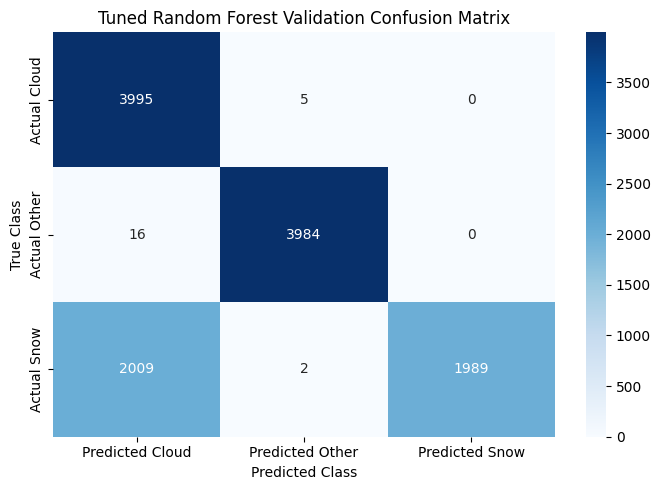

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Get class labels from the trained model
class_labels = best_rf.classes_

# Create confusion matrix
cm = confusion_matrix(y_val, val_pred, labels=class_labels)

# Put into a labeled dataframe
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)

# Plot heat map
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Tuned Random Forest Validation Confusion Matrix")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

## 9. Feature importance


In [18]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance


,Feature,Importance
6,NDSI,0.264073
0,Blue,0.215876
1,Green,0.188737
4,SWIR,0.175540
2,Red,0.093143
3,NIR,0.034399
5,NDVI,0.028231


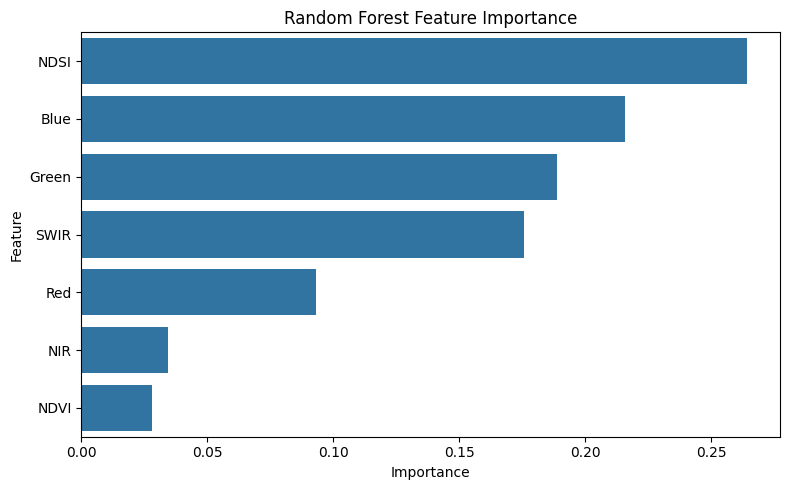

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. Save validation model



In [ ]:
val_results = val_2024.copy()
val_results["Predicted_Class"] = val_pred

output_path_val = os.path.join(base_path, "rf_val_predictions.csv")
val_results.to_csv(output_path_val, index=False)

print("Saved validation predictions to:", output_path_val)

## 11. Final model using train + validation

After choosing the best hyperparameters based on validation performance, you can retrain using both the original training data and validation data, then evaluate once on the held-out test set.


In [20]:
final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train)
X_test_final_scaled = final_scaler.transform(X_test)

final_rf = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_final_scaled, y_train)

test_pred = final_rf.predict(X_test_final_scaled)

print("Final test accuracy:", accuracy_score(y_test, test_pred))
print("\nFinal test classification report:")
print(classification_report(y_test, test_pred))
print("\nFinal test confusion matrix:")
print(confusion_matrix(y_test, test_pred))


Final test accuracy: 0.9254104508709059

Final test classification report:
              precision    recall  f1-score   support

       Cloud       0.96      0.98      0.97      4000
       Other       0.85      0.98      0.91      4000
        Snow       1.00      0.82      0.90      3999

    accuracy                           0.93     11999
   macro avg       0.93      0.93      0.92     11999
weighted avg       0.93      0.93      0.92     11999


Final test confusion matrix:
[[3921   79    0]
 [  87 3913    0]
 [  95  634 3270]]


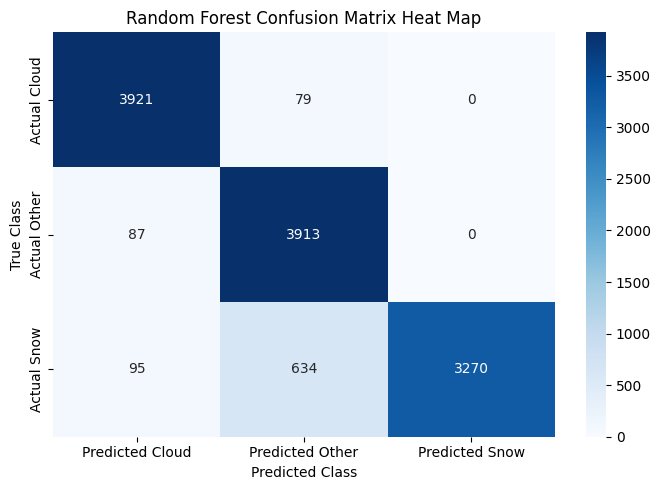

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Get class names in the same order the model uses
class_labels = final_rf.classes_

# Create confusion matrix
cm = confusion_matrix(y_test, test_pred, labels=class_labels)

# Convert to DataFrame for nicer labels
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)

# Plot heat map
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix Heat Map")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

## 12. Save predictions (optional)


In [ ]:
test_results = test_2025.copy()
test_results["Predicted_Class"] = test_pred

output_path = os.path.join(base_path, "rf_test_predictions.csv")
test_results.to_csv(output_path, index=False)

print("Saved predictions to:", output_path)
